# 10. Odds, log-odds, odds ratio, Fisher, chi-square i Wald bez `statsmodels`

Ten notebook jest poprawioną i rozszerzoną wersją materiału o odds i odds ratio. Nie używa `statsmodels`; regresję logistyczną dla tabeli 2×2 dopasujemy ręcznie metodą Newtona/IRLS.

Główna ścieżka dydaktyczna:

1. $p$ to prawdopodobieństwo.
2. $odds$ to stosunek „sukcesów” do „porażek”.
3. $log(odds)$ zamienia zakres $(0,\infty)$ na $(-\infty,\infty)$.
4. $odds\ ratio$ porównuje odds między dwiema grupami.
5. $log(odds\ ratio)$ jest współczynnikiem w prostej regresji logistycznej z predyktorem 0/1.
6. Fisher, chi-square i Wald to trzy różne sposoby testowania związku w tabeli 2×2.

In [58]:
import math
from math import comb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import hypergeom, chi2, norm, fisher_exact, chi2_contingency

pd.set_option('display.precision', 6)

## 1. Probability, odds i log-odds

Prawdopodobieństwo:

$$
0 \le p \le 1
$$

Odds:

$$
odds = \frac{p}{1-p}
$$

Odwrotne przejście:

$$
p = \frac{odds}{1+odds}
$$

Log-odds, czyli logit:

$$
logit(p) = \log\left(\frac{p}{1-p}\right)
$$

Dlaczego logit jest wygodny? Bo $p$ żyje w przedziale $[0,1]$, ale $logit(p)$ żyje na całej osi rzeczywistej. Dzięki temu możemy modelować go liniowo:

$$
logit(p) = X\beta
$$

Jasne — wersja z dolarami:

### Intuicja: odds(+), odds(-) i przejście do probability

Załóżmy:

- liczba sukcesów: $N_{+}$
- liczba porażek: $N_{-}$

Wtedy prawdopodobieństwo sukcesu to:

$$
p = \frac{N_{+}}{N_{+}+N_{-}}
$$

---

### Odds jako stosunek sukcesów do porażek

Definiujemy odds:

$$
\mathrm{odds} = \frac{N_{+}}{N_{-}}
$$

czyli:

- odds $>1$ → sukces bardziej prawdopodobny,
- odds $=1$ → sytuacja 50/50,
- odds $<1$ → porażka bardziej prawdopodobna.

---

### Przykład

Załóżmy:

- $N_{+}=80$
- $N_{-}=20$

Wtedy:

$$
p=\frac{80}{80+20}=0.8
$$

Odds:

$$
\mathrm{odds}=\frac{80}{20}=4
$$

---

### Odwrotne przejście: odds → probability

Mamy:

$$
\mathrm{odds}=\frac{p}{1-p}
$$

Po przekształceniu:

$$
p=\frac{\mathrm{odds}}{1+\mathrm{odds}}
$$

Dla naszego przykładu:

$$
p=\frac{4}{1+4}=\frac{4}{5}=0.8
$$

---

### Ważna intuicja

Probability mówi:

> „jaka część wszystkich przypadków to sukces?”

Odds mówi:

> „ile razy sukces jest bardziej prawdopodobny niż porażka?”



Dla:

$$
p=\frac{4}{5}=0.8
$$

mamy:

$$
1-p=\frac{1}{5}=0.2
$$

więc odds to:

$$
\mathrm{odds}=\frac{p}{1-p}
=\frac{\frac{4}{5}}{\frac{1}{5}}
=\frac{4}{1}
$$

Jeśli odds wynosi $4$, to:

$$
p=\frac{4}{1+4}=\frac{4}{5}=0.8
$$

A sprawdzając w drugą stronę:

$$
\mathrm{odds}
=
\frac{p}{1-p}
=
\frac{\frac{4}{5}}{\frac{1}{5}}
=
4
$$

### Krótkie ćwiczenie dla studentów:

### Ćwiczenie: probability, odds i odds ratio

Uzupełnij brakujące wartości.

| Grupa | $N_{+}$ | $N_{-}$ | $p$ | odds |
|---|---:|---:|---:|---:|
| A | 30 | 10 | ? | ? |
| B | 20 | 20 | ? | ? |

1. Policz prawdopodobieństwo sukcesu w grupie A:

$$
p_A = \frac{N_+}{N_+ + N_-}
$$

2. Policz odds w grupie A:

$$
\mathrm{odds}_A = \frac{N_+}{N_-}
$$

3. Policz prawdopodobieństwo sukcesu w grupie B.

4. Policz odds w grupie B.

5. Policz odds ratio:

$$
OR = \frac{\mathrm{odds}_A}{\mathrm{odds}_B}
$$

6. Zinterpretuj wynik jednym zdaniem.

### Jak czytać odds zapisane jako `2:3` albo `3:5`?

Zapis **odds = 2:3** oznacza:

- 2 sukcesy,
- 3 porażki,
- razem 5 obserwacji.

To **nie** znaczy, że prawdopodobieństwo wynosi $2/3$.

Jeśli odds zapisujemy jako $a:b$, to:

$$
odds = \frac{a}{b}
$$

ale prawdopodobieństwo sukcesu wynosi:

$$
p = \frac{a}{a+b}
$$

Czyli:

- w odds mianownik to liczba **porażek**,
- w prawdopodobieństwie mianownik to liczba **wszystkich obserwacji**.


In [77]:
odds_examples = pd.DataFrame({
    'odds zapisane jako': ['2:3', '3:5'],
    'sukcesy': [2, 3],
    'porażki': [3, 5],
})

odds_examples['razem'] = odds_examples['sukcesy'] + odds_examples['porażki']
odds_examples['odds jako liczba'] = odds_examples['sukcesy'] / odds_examples['porażki']
odds_examples['p = sukcesy / razem'] = odds_examples['sukcesy'] / odds_examples['razem']
odds_examples['log_odds = log(odds)'] = np.log(odds_examples['odds jako liczba'])

odds_examples


,odds zapisane jako,sukcesy,porażki,razem,odds jako liczba,p = sukcesy / razem,log_odds = log(odds)
0,2:3,2,3,5,0.6667,0.400,-0.4055
1,3:5,3,5,8,0.6000,0.375,-0.5108


### Odpowiedź

Grupa A:

$$
p_A = \frac{30}{30+10}=\frac{30}{40}=0.75
$$

$$
\mathrm{odds}_A=\frac{30}{10}=3
$$

Grupa B:

$$
p_B = \frac{20}{20+20}=\frac{20}{40}=0.5
$$

$$
\mathrm{odds}_B=\frac{20}{20}=1
$$

Odds ratio:

$$
OR=\frac{3}{1}=3
$$

Interpretacja:

> Odds sukcesu w grupie A są 3 razy większe niż odds sukcesu w grupie B.

Pokazać przykład z drużyną dla słabej i dobrej drużyny: 1/32, 1/64... 
Dobra drużyna 2/1, 5/1,100/1


### Intuicja sportowa: słaba i dobra drużyna

Odds można rozumieć jako proporcję:

$$
\text{sukces} : \text{porażka}
$$

czyli np. szansa wygranej drużyny względem szansy przegranej.

---

### Słaba drużyna

$$
\mathrm{odds}=\frac{1}{1}
$$

to znaczy, że proporcja wygrana : przegrana wynosi:

$$
1:1
$$


$$
\mathrm{odds}=\frac{1}{2}
$$

to znaczy, że proporcja wygrana : przegrana wynosi:

$$
1:2
$$
Jeśli słaba drużyna ma odds:

$$
\mathrm{odds}=\frac{1}{32}
$$

to znaczy, że proporcja wygrana : przegrana wynosi:

$$
1:32
$$

Czyli na łącznie $1+32=33$ części tylko jedna odpowiada wygranej.

Prawdopodobieństwo wygranej:

$$
p=\frac{1}{1+32}=\frac{1}{33}\approx 0.030
$$

czyli około $3.0\%$.

Jeszcze słabsza drużyna:

$$
\mathrm{odds}=\frac{1}{64}
$$

oznacza proporcję:

$$
1:64
$$

więc:

$$
p=\frac{1}{1+64}=\frac{1}{65}\approx 0.015
$$

czyli około $1.5\%$.

---

### Dobra drużyna

Jeśli dobra drużyna ma odds:

$$
\mathrm{odds}=\frac{2}{1}
$$

to znaczy, że proporcja wygrana : przegrana wynosi:

$$
2:1
$$

czyli:

$$
p=\frac{2}{2+1}=\frac{2}{3}\approx 0.667
$$

czyli około $66.7\%$.

Jeśli drużyna ma odds:

$$
\mathrm{odds}=\frac{5}{1}
$$

to:

$$
p=\frac{5}{5+1}=\frac{5}{6}\approx 0.833
$$

czyli około $83.3\%$.

Bardzo silna drużyna:

$$
\mathrm{odds}=\frac{100}{1}
$$

oznacza:

$$
100:1
$$

więc:

$$
p=\frac{100}{100+1}=\frac{100}{101}\approx 0.990
$$

czyli około $99.0\%$.

---

### Wniosek

Odds mniejsze niż $1$ oznaczają, że sukces jest mniej prawdopodobny niż porażka.

Odds równe $1$ oznaczają sytuację $50/50$.

Odds większe niż $1$ oznaczają, że sukces jest bardziej prawdopodobny niż porażka.

In [71]:
odds=1/6

In [72]:
log(odds)

-1.791759469228055

In [73]:
log(1/odds)

1.791759469228055

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 4)

odds_values = np.array([
    1/64, 1/32, 1/16, 1/8, 1/4, 1/2,
    1,
    2, 5, 10, 20, 50, 100
])

df_odds = pd.DataFrame({
    "odds": odds_values,
})

df_odds["p"] = df_odds["odds"] / (1 + df_odds["odds"])
df_odds["1-p"] = 1 - df_odds["p"]
df_odds["log_odds"] = np.log(df_odds["odds"])

df_odds

,odds,p,1-p,log_odds
0,0.0156,0.0154,0.9846,-4.1589
1,0.0312,0.0303,0.9697,-3.4657
2,0.0625,0.0588,0.9412,-2.7726
3,0.1250,0.1111,0.8889,-2.0794
4,0.2500,0.2000,0.8000,-1.3863
5,0.5000,0.3333,0.6667,-0.6931
6,1.0000,0.5000,0.5000,0.0000
7,2.0000,0.6667,0.3333,0.6931
8,5.0000,0.8333,0.1667,1.6094
9,10.0000,0.9091,0.0909,2.3026


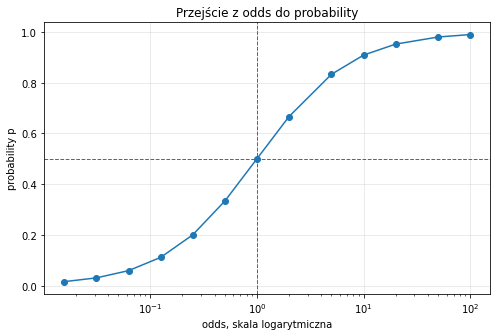

In [75]:
plt.figure(figsize=(8, 5))

plt.plot(df_odds["odds"], df_odds["p"], marker="o")

plt.xscale("log")
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.axvline(1, linestyle="--", linewidth=1)

plt.xlabel("odds, skala logarytmiczna")
plt.ylabel("probability p")
plt.title("Przejście z odds do probability")

plt.grid(True, alpha=0.3)
plt.show()

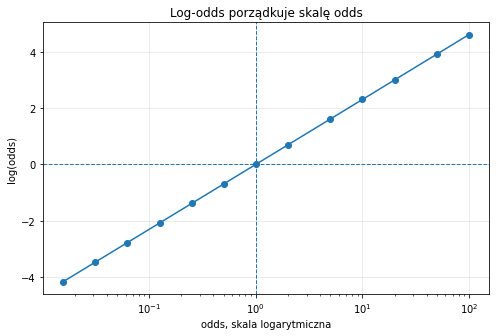

In [76]:
plt.figure(figsize=(8, 5))

plt.plot(df_odds["odds"], df_odds["log_odds"], marker="o")

plt.xscale("log")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(1, linestyle="--", linewidth=1)

plt.xlabel("odds, skala logarytmiczna")
plt.ylabel("log(odds)")
plt.title("Log-odds porządkuje skalę odds")

plt.grid(True, alpha=0.3)
plt.show()

---

### Odds ratio

Odds ratio porównuje odds w dwóch grupach.

Załóżmy teraz dwie grupy:

| Grupa | $N_{+}$ | $N_{-}$ | $p$ | odds |
|---|---:|---:|---:|---:|
| A | 80 | 20 | $0.8$ | $4$ |
| B | 50 | 50 | $0.5$ | $1$ |

W grupie A:

$$
\mathrm{odds}_A = \frac{80}{20}=4
$$

W grupie B:

$$
\mathrm{odds}_B = \frac{50}{50}=1
$$

Odds ratio:

$$
OR = \frac{\mathrm{odds}_A}{\mathrm{odds}_B}
$$

czyli:

$$
OR = \frac{4}{1}=4
$$

Interpretacja:

> Odds sukcesu w grupie A są 4 razy większe niż odds sukcesu w grupie B.

Uwaga: to nie znaczy, że prawdopodobieństwo jest 4 razy większe.  
Prawdopodobieństwa wynoszą:

$$
p_A=0.8
$$

$$
p_B=0.5
$$

czyli stosunek prawdopodobieństw to:

$$
\frac{p_A}{p_B}=\frac{0.8}{0.5}=1.6
$$

Dlatego odds ratio i ratio prawdopodobieństw to nie to samo.

In [59]:
probabilities = np.array([0.01, 0.05, 0.10, 0.20, 0.50, 0.80, 0.90, 0.95, 0.99])
odds = probabilities / (1 - probabilities)
log_odds = np.log(odds)

pd.DataFrame({
    'p': probabilities,
    'odds = p/(1-p)': odds,
    'log_odds = log(odds)': log_odds,
})

,p,odds = p/(1-p),log_odds = log(odds)
0,0.01,0.010101,-4.595120
1,0.05,0.052632,-2.944439
2,0.10,0.111111,-2.197225
3,0.20,0.250000,-1.386294
4,0.50,1.000000,0.000000
5,0.80,4.000000,1.386294
6,0.90,9.000000,2.197225
7,0.95,19.000000,2.944439
8,0.99,99.000000,4.595120


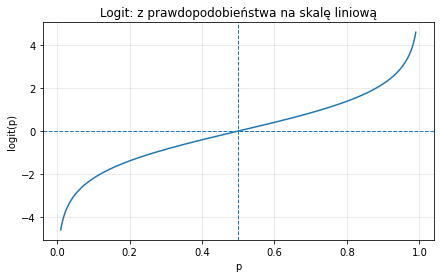

In [60]:
p_grid = np.linspace(0.01, 0.99, 300)
logit_grid = np.log(p_grid / (1 - p_grid))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p_grid, logit_grid)
ax.axhline(0, linewidth=1, linestyle='--')
ax.axvline(0.5, linewidth=1, linestyle='--')
ax.set_xlabel('p')
ax.set_ylabel('logit(p)')
ax.set_title('Logit: z prawdopodobieństwa na skalę liniową')
ax.grid(True, alpha=0.3)
plt.show()

## 2. Odds ratio dla tabeli 2×2

Użyjemy klasycznej małej tabeli:

$$
\begin{array}{c|cc}
 & Cancer=Yes & Cancer=No \\
\hline
Mutated=Yes & a & b \\
Mutated=No & c & d
\end{array}
$$

Wtedy:

$$
odds_{mutated} = \frac{a}{b}
$$

$$
odds_{not\ mutated} = \frac{c}{d}
$$

$$
OR = \frac{a/b}{c/d}=\frac{ad}{bc}
$$

oraz:

$$
\log(OR)=\log\left(\frac{ad}{bc}\right)
$$

In [61]:
obs = np.array([[23, 117],
                [ 6, 210]])
counts = pd.DataFrame(obs,
                      index=['Mutated gene: Yes', 'Mutated gene: No'],
                      columns=['Cancer: Yes', 'Cancer: No'])
counts

,Cancer: Yes,Cancer: No
Mutated gene: Yes,23,117
Mutated gene: No,6,210


In [62]:
a, b, c, d = obs.ravel()
odds_mutated = a / b
odds_not_mutated = c / d
odds_ratio = (a*d) / (b*c)
log_odds_ratio = math.log(odds_ratio)

pd.Series({
    'odds_mutated = 23/117': odds_mutated,
    'odds_not_mutated = 6/210': odds_not_mutated,
    'OR = (23*210)/(117*6)': odds_ratio,
    'log(OR)': log_odds_ratio,
})

odds_mutated = 23/117       0.196581
odds_not_mutated = 6/210    0.028571
OR = (23*210)/(117*6)       6.880342
log(OR)                     1.928668
dtype: float64

Interpretacja:

- $OR=1$: brak różnicy odds między grupami,
- $OR>1$: odds są większe w grupie `Mutated=Yes`,
- $OR<1$: odds są mniejsze w grupie `Mutated=Yes`,
- $\log(OR)=0$: brak różnicy,
- dodatni $\log(OR)$: większe odds w pierwszej grupie,
- ujemny $\log(OR)$: mniejsze odds w pierwszej grupie.

## 3. Test Fishera ręcznie

Test Fishera zakłada ustalone sumy brzegowe. Pod hipotezą zerową liczba przypadków `Cancer=Yes` w grupie `Mutated=Yes` ma rozkład hipergeometryczny.

Dla tabeli:

$$
\begin{array}{c|cc|c}
 & Cancer=Yes & Cancer=No & row\ sum \\
\hline
Mutated=Yes & a & b & a+b \\
Mutated=No & c & d & c+d \\
\hline
col\ sum & a+c & b+d & n
\end{array}
$$

Jeśli $X$ oznacza liczbę przypadków `Cancer=Yes` w pierwszym wierszu, to:

$$
X \sim Hypergeometric(N, K, n_1)
$$

gdzie:

- $N$ to łączna liczba obserwacji,
- $K$ to liczba wszystkich przypadków `Cancer=Yes`,
- $n_1$ to liczba obserwacji w grupie `Mutated=Yes`.

In [63]:
row_sums = obs.sum(axis=1)
col_sums = obs.sum(axis=0)
N_total = obs.sum()
K_successes = col_sums[0]
n_draws = row_sums[0]
observed_x = obs[0, 0]

x_min = max(0, n_draws - col_sums[1])
x_max = min(n_draws, K_successes)
xs = np.arange(x_min, x_max + 1)
pmfs = hypergeom.pmf(xs, N_total, K_successes, n_draws)

fisher_table = pd.DataFrame({'x = Cancer Yes in Mutated group': xs, 'probability under H0': pmfs})
fisher_table.loc[fisher_table['x = Cancer Yes in Mutated group'].between(observed_x-3, observed_x+3)]

,x = Cancer Yes in Mutated group,probability under H0
20,20,5.729462e-04
21,21,1.416625e-04
22,22,2.933074e-05
23,23,5.015981e-06
24,24,6.953433e-07
25,25,7.609417e-08
26,26,6.320571e-09


In [64]:
p_observed = hypergeom.pmf(observed_x, N_total, K_successes, n_draws)
p_left = hypergeom.cdf(observed_x, N_total, K_successes, n_draws)
p_right = hypergeom.sf(observed_x - 1, N_total, K_successes, n_draws)
p_two_sided = pmfs[pmfs <= p_observed + 1e-15].sum()

scipy_or, scipy_fisher_p = fisher_exact(obs, alternative='two-sided')

pd.Series({
    'observed_x': observed_x,
    'P(observed table)': p_observed,
    'one_sided_left_P(X <= observed)': p_left,
    'one_sided_right_P(X >= observed)': p_right,
    'two_sided_manual_sum_of_as_or_more_extreme_probs': p_two_sided,
    'scipy_fisher_two_sided_p': scipy_fisher_p,
})

observed_x                                          23.000000
P(observed table)                                    0.000005
one_sided_left_P(X <= observed)                      0.999999
one_sided_right_P(X >= observed)                     0.000006
two_sided_manual_sum_of_as_or_more_extreme_probs     0.000011
scipy_fisher_two_sided_p                             0.000011
dtype: float64

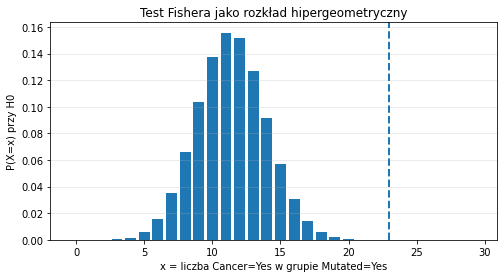

In [65]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(xs, pmfs)
ax.axvline(observed_x, linestyle='--', linewidth=2)
ax.set_xlabel('x = liczba Cancer=Yes w grupie Mutated=Yes')
ax.set_ylabel('P(X=x) przy H0')
ax.set_title('Test Fishera jako rozkład hipergeometryczny')
ax.grid(True, axis='y', alpha=0.3)
plt.show()

## 4. Test chi-square ręcznie

Test chi-square porównuje liczebności obserwowane z oczekiwanymi przy niezależności.

Liczebność oczekiwana w komórce:

$$
E_{ij}=\frac{row_i\ sum \cdot col_j\ sum}{N}
$$

Statystyka:

$$
\chi^2 = \sum_{i,j}\frac{(O_{ij}-E_{ij})^2}{E_{ij}}
$$

Dla tabeli 2×2 stopnie swobody:

$$
df=(2-1)(2-1)=1
$$

In [48]:
expected = np.outer(row_sums, col_sums) / N_total
chi_square_stat = ((obs - expected)**2 / expected).sum()
chi_square_p = chi2.sf(chi_square_stat, df=1)

chi2_scipy, p_scipy, dof_scipy, expected_scipy = chi2_contingency(obs, correction=False)

pd.DataFrame(expected, index=counts.index, columns=counts.columns)

,Cancer: Yes,Cancer: No
Mutated gene: Yes,11.404494,128.595506
Mutated gene: No,17.595506,198.404494


In [49]:
pd.Series({
    'chi_square_manual': chi_square_stat,
    'p_manual': chi_square_p,
    'chi_square_scipy_no_yates': chi2_scipy,
    'p_scipy_no_yates': p_scipy,
    'df': dof_scipy,
})

chi_square_manual            21.154455
p_manual                      0.000004
chi_square_scipy_no_yates    21.154455
p_scipy_no_yates              0.000004
df                            1.000000
dtype: float64

### Korekta Yatesa

W wielu narzędziach dla tabel 2×2 domyślnie może pojawić się korekta ciągłości Yatesa. Wtedy zamiast $|O-E|$ używa się $|O-E|-0.5$.

W notebooku główny rachunek pokazujemy bez korekty, bo dydaktycznie łatwiej zobaczyć zwykłą konstrukcję testu chi-square.

In [50]:
yates_stat = (((np.abs(obs - expected) - 0.5)**2) / expected).sum()
yates_p = chi2.sf(yates_stat, df=1)
chi2_yates_scipy, p_yates_scipy, _, _ = chi2_contingency(obs, correction=True)

pd.Series({
    'chi_square_yates_manual': yates_stat,
    'p_yates_manual': yates_p,
    'chi_square_yates_scipy': chi2_yates_scipy,
    'p_yates_scipy': p_yates_scipy,
})

chi_square_yates_manual    19.369422
p_yates_manual              0.000011
chi_square_yates_scipy     19.369422
p_yates_scipy               0.000011
dtype: float64

## 5. Test Walda dla $\log(OR)$

Przy większych liczebnościach przybliżony błąd standardowy log odds ratio to:

$$
SE(\log(OR)) = \sqrt{\frac{1}{a}+\frac{1}{b}+\frac{1}{c}+\frac{1}{d}}
$$

Statystyka Walda:

$$
z = \frac{\log(OR)}{SE(\log(OR))}
$$

p-value dwustronne:

$$
p = 2P(Z>|z|)
$$

Przedział ufności dla odds ratio:

$$
\exp\left(\log(OR) \pm 1.96\cdot SE\right)
$$

In [51]:
se_log_or = math.sqrt(1/a + 1/b + 1/c + 1/d)
z_wald = log_odds_ratio / se_log_or
p_wald = 2 * norm.sf(abs(z_wald))
ci_log_low = log_odds_ratio - 1.96 * se_log_or
ci_log_high = log_odds_ratio + 1.96 * se_log_or

pd.Series({
    'log_OR': log_odds_ratio,
    'SE_log_OR': se_log_or,
    'z_Wald': z_wald,
    'p_Wald': p_wald,
    'OR': odds_ratio,
    'OR_CI_low': math.exp(ci_log_low),
    'OR_CI_high': math.exp(ci_log_high),
})

log_OR         1.928668
SE_log_OR      0.472709
z_Wald         4.080033
p_Wald         0.000045
OR             6.880342
OR_CI_low      2.724156
OR_CI_high    17.377531
dtype: float64

## 6. Połączenie z regresją logistyczną

Dla tabeli 2×2 możemy rozwinąć dane do postaci indywidualnych obserwacji i dopasować model:

$$
logit(P(Cancer=Yes)) = \beta_0 + \beta_1 I(Mutated=Yes)
$$

Wtedy:

- $\beta_0$ to log-odds dla grupy referencyjnej `Mutated=No`,
- $\beta_1$ to $\log(OR)$,
- $\exp(\beta_1)$ to $OR$.

Poniżej dopasujemy ten model ręcznie metodą Newtona/IRLS.

In [52]:
def sigmoid(z):
    z = np.asarray(z, dtype=float)
    z = np.clip(z, -35, 35)
    return 1 / (1 + np.exp(-z))


def loglik_logistic(beta, X, y):
    eta = X @ beta
    return float(np.sum(y * eta - np.logaddexp(0, eta)))


def fit_logistic_irls(X, y, l2=0.0, max_iter=100, tol=1e-10):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n, k = X.shape
    beta = np.zeros(k)
    penalty = np.eye(k)
    penalty[0, 0] = 0.0  # nie karzemy interceptu
    converged = False
    for iteration in range(max_iter):
        eta = X @ beta
        p = sigmoid(eta)
        W = p * (1 - p)
        gradient = X.T @ (y - p) - l2 * (penalty @ beta)
        information = (X.T * W) @ X + l2 * penalty
        step = np.linalg.pinv(information) @ gradient
        beta_new = beta + step
        if np.max(np.abs(step)) < tol:
            beta = beta_new
            converged = True
            break
        beta = beta_new
    eta = X @ beta
    p = sigmoid(eta)
    W = p * (1 - p)
    information = (X.T * W) @ X + l2 * penalty
    cov_beta = np.linalg.pinv(information)
    se_beta = np.sqrt(np.diag(cov_beta))
    ll = loglik_logistic(beta, X, y)
    return {
        'beta': beta,
        'se': se_beta,
        'cov': cov_beta,
        'll': ll,
        'converged': converged,
        'iterations': iteration + 1,
        'p_hat': p,
    }


def expand_2x2_counts(a, b, c, d):
    # Mutated=1: a cancer cases, b non-cases; Mutated=0: c cancer cases, d non-cases.
    rows = []
    rows += [{'mutated': 1, 'cancer': 1}] * int(a)
    rows += [{'mutated': 1, 'cancer': 0}] * int(b)
    rows += [{'mutated': 0, 'cancer': 1}] * int(c)
    rows += [{'mutated': 0, 'cancer': 0}] * int(d)
    return pd.DataFrame(rows)

expanded = expand_2x2_counts(a, b, c, d)
X_logit = np.column_stack([np.ones(len(expanded)), expanded['mutated'].to_numpy()])
y_logit = expanded['cancer'].to_numpy()
fit_logit_2x2 = fit_logistic_irls(X_logit, y_logit)
fit_logit_2x2['converged'], fit_logit_2x2['iterations']

(True, 8)

In [53]:
coef_table_logit = pd.DataFrame({
    'coef': fit_logit_2x2['beta'],
    'std_error': fit_logit_2x2['se'],
})
coef_table_logit['z'] = coef_table_logit['coef'] / coef_table_logit['std_error']
coef_table_logit['p_value_Wald'] = 2 * norm.sf(np.abs(coef_table_logit['z']))
coef_table_logit.index = ['intercept_log_odds_Mutated_No', 'log_OR_Mutated_Yes_vs_No']
coef_table_logit

,coef,std_error,z,p_value_Wald
intercept_log_odds_Mutated_No,-3.555348,0.414039,-8.586981,8.928411e-18
log_OR_Mutated_Yes_vs_No,1.928668,0.472709,4.080033,4.502937e-05


In [54]:
pd.Series({
    'beta_1_from_logistic_regression': fit_logit_2x2['beta'][1],
    'manual_log_OR': log_odds_ratio,
    'exp(beta_1)': math.exp(fit_logit_2x2['beta'][1]),
    'manual_OR': odds_ratio,
})

beta_1_from_logistic_regression    1.928668
manual_log_OR                      1.928668
exp(beta_1)                        6.880342
manual_OR                          6.880342
dtype: float64

## Prosta na skali log-odds: skąd bierze się współczynnik w logistic regression?

Dla tabeli 2×2 możemy zakodować zmienną:

$$
x=0
$$

jako brak mutacji oraz:

$$
x=1
$$

jako mutację.

Regresja logistyczna modeluje prostą na skali log-odds:

$$
logit(p)=b_0+b_1x
$$

Dla grupy bez mutacji:

$$
b_0=\log\left(\frac{c}{d}\right)
$$

Dla grupy z mutacją:

$$
b_0+b_1=\log\left(\frac{a}{b}\right)
$$

Stąd:

$$
b_1=\log\left(\frac{a/b}{c/d}\right)=\log(OR)
$$

Czyli współczynnik przy zmiennej binarnej w regresji logistycznej jest logarytmem odds ratio.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log, exp

# Tabela 2x2:
#                Rak+  Rak-
# Mutacja+        a     b
# Mutacja-        c     d

a, b, c, d = 23, 117, 6, 210

# Odds w grupie bez mutacji: x = 0
odds_no_mutation = c / d
log_odds_no_mutation = log(odds_no_mutation)

# Odds w grupie z mutacją: x = 1
odds_mutation = a / b
log_odds_mutation = log(odds_mutation)

# Parametry prostej na skali log-odds
b0 = log_odds_no_mutation
b1 = log_odds_mutation - log_odds_no_mutation

OR = odds_mutation / odds_no_mutation

print(f"b0 = log odds dla x=0 = {b0:.3f}")
print(f"b1 = log(OR) = {b1:.3f}")
print(f"OR = exp(b1) = {exp(b1):.3f}")

line_demo = pd.DataFrame({
    "x": [0, 1],
    "group": ["brak mutacji", "mutacja"],
    "odds": [odds_no_mutation, odds_mutation],
    "log_odds": [log_odds_no_mutation, log_odds_mutation],
})

line_demo

b0 = log odds dla x=0 = -3.555
b1 = log(OR) = 1.929
OR = exp(b1) = 6.880


,x,group,odds,log_odds
0,0,brak mutacji,0.028571,-3.555348
1,1,mutacja,0.196581,-1.626680


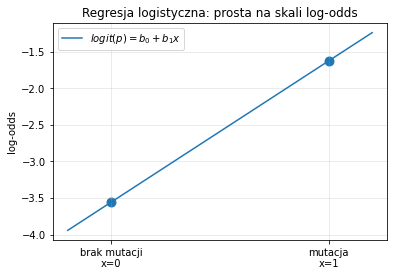

In [56]:
x_grid = np.linspace(-0.2, 1.2, 100)
log_odds_grid = b0 + b1 * x_grid

plt.figure(figsize=(6, 4))

plt.plot(x_grid, log_odds_grid, label=r"$logit(p)=b_0+b_1x$")
plt.scatter([0, 1], [log_odds_no_mutation, log_odds_mutation], s=80)

plt.xticks([0, 1], ["brak mutacji\nx=0", "mutacja\nx=1"])
plt.ylabel("log-odds")
plt.title("Regresja logistyczna: prosta na skali log-odds")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

Na skali log-odds regresja logistyczna jest zwykłą prostą.

- punkt dla `x=0` to log-odds w grupie bez mutacji,
- punkt dla `x=1` to log-odds w grupie z mutacją,
- nachylenie prostej to:

$$
b_1=\log(OR)
$$

Po odlogarytmowaniu dostajemy:

$$
e^{b_1}=OR
$$

Najpierw model logistyczny tworzy probability:

$$
p(x)=P(y=1 \mid x)
$$

Dopiero threshold zamienia probability na klasę 0/1.

ROC pokazuje, co się dzieje, gdy przesuwamy threshold.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Przykładowe dane 1D
X = np.array([[2], [4], [5], [6], [8], [9], [10], [12]])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# Model logistyczny
clf = LogisticRegression()
clf.fit(X, y)

# Siatka x do rysowania krzywej
x_grid = np.linspace(X.min() - 1, X.max() + 1, 300).reshape(-1, 1)
p_grid = clf.predict_proba(x_grid)[:, 1]

# Wykres
plt.figure(figsize=(6, 4))

# Punkty danych
plt.scatter(X[y == 0], y[y == 0], marker='x', s=80, label='klasa 0')
plt.scatter(X[y == 1], y[y == 1], marker='o', s=80, label='klasa 1')

# Krzywa logistyczna
plt.plot(x_grid, p_grid, label='sigmoida logistyczna')

# Threshold 0.5
plt.axhline(0.5, linestyle='--', alpha=0.7, label='threshold p=0.5')

plt.xlabel('cecha x')
plt.ylabel('P(y=1 | x)')
plt.title('Regresja logistyczna: sigmoida + punkty 0/1')
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 7. Mini-ćwiczenia

### Ćwiczenie A: odds i log-odds

Jeśli $p=0.8$, to:

$$
odds=\frac{0.8}{0.2}=4
$$

$$
log(odds)=\log(4)\approx 1.386
$$

### Ćwiczenie B: odds ratio

Dla tabeli:

$$
\begin{array}{c|cc}
 & Yes & No \\
\hline
Group A & 8 & 2 \\
Group B & 4 & 6
\end{array}
$$

$$
OR=\frac{8\cdot 6}{2\cdot 4}=6
$$

### Ćwiczenie C: interpretacja $\log(OR)$

Jeśli $\log(OR)=0$, to $OR=1$, czyli brak różnicy odds między grupami.

## 8. Checklista prowadzącego

Po tym notebooku student powinien umieć:

1. Przeliczyć $p \leftrightarrow odds \leftrightarrow log(odds)$.
2. Policzyć $OR = ad/bc$ dla tabeli 2×2.
3. Wyjaśnić, dlaczego $\log(OR)$ jest naturalny w regresji logistycznej.
4. Ręcznie policzyć oczekiwane liczebności w teście chi-square.
5. Wyjaśnić, że Fisher liczy prawdopodobieństwa tabel przy ustalonych marginesach.
6. Policzyć test Walda dla $\log(OR)$.

## Prosta na skali log-odds: skąd bierze się współczynnik w logistic regression?

Dla tabeli 2×2 możemy zakodować zmienną:

$$
x=0
$$

jako brak mutacji oraz:

$$
x=1
$$

jako mutację.

Regresja logistyczna modeluje prostą na skali log-odds:

$$
logit(p)=b_0+b_1x
$$

Dla grupy bez mutacji:

$$
b_0=\log\left(\frac{c}{d}\right)
$$

Dla grupy z mutacją:

$$
b_0+b_1=\log\left(\frac{a}{b}\right)
$$

Stąd:

$$
b_1=\log\left(\frac{a/b}{c/d}\right)=\log(OR)
$$

Czyli współczynnik przy zmiennej binarnej w regresji logistycznej jest logarytmem odds ratio.

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log, exp

# Tabela 2x2:
#                Rak+  Rak-
# Mutacja+        a     b
# Mutacja-        c     d

a, b, c, d = 23, 117, 6, 210

# Odds w grupie bez mutacji: x = 0
odds_no_mutation = c / d
log_odds_no_mutation = log(odds_no_mutation)

# Odds w grupie z mutacją: x = 1
odds_mutation = a / b
log_odds_mutation = log(odds_mutation)

# Parametry prostej na skali log-odds
b0 = log_odds_no_mutation
b1 = log_odds_mutation - log_odds_no_mutation

OR = odds_mutation / odds_no_mutation

print(f"b0 = log odds dla x=0 = {b0:.3f}")
print(f"b1 = log(OR) = {b1:.3f}")
print(f"OR = exp(b1) = {exp(b1):.3f}")

line_demo = pd.DataFrame({
    "x": [0, 1],
    "group": ["brak mutacji", "mutacja"],
    "odds": [odds_no_mutation, odds_mutation],
    "log_odds": [log_odds_no_mutation, log_odds_mutation],
})

line_demo

b0 = log odds dla x=0 = -3.555
b1 = log(OR) = 1.929
OR = exp(b1) = 6.880


,x,group,odds,log_odds
0,0,brak mutacji,0.028571,-3.555348
1,1,mutacja,0.196581,-1.626680


In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log, exp

# Tabela 2x2:
#                Rak+  Rak-
# Mutacja+        a     b
# Mutacja-        c     d

a, b, c, d = 23, 117, 6, 210

# Odds w grupie bez mutacji: x = 0
odds_no_mutation = c / d
log_odds_no_mutation = log(odds_no_mutation)

# Odds w grupie z mutacją: x = 1
odds_mutation = a / b
log_odds_mutation = log(odds_mutation)

# Parametry prostej na skali log-odds
b0 = log_odds_no_mutation
b1 = log_odds_mutation - log_odds_no_mutation

OR = odds_mutation / odds_no_mutation

print(f"b0 = log odds dla x=0 = {b0:.3f}")
print(f"b1 = log(OR) = {b1:.3f}")
print(f"OR = exp(b1) = {exp(b1):.3f}")

line_demo = pd.DataFrame({
    "x": [0, 1],
    "group": ["brak mutacji", "mutacja"],
    "odds": [odds_no_mutation, odds_mutation],
    "log_odds": [log_odds_no_mutation, log_odds_mutation],
})

line_demo

b0 = log odds dla x=0 = -3.555
b1 = log(OR) = 1.929
OR = exp(b1) = 6.880


,x,group,odds,log_odds
0,0,brak mutacji,0.028571,-3.555348
1,1,mutacja,0.196581,-1.626680
